# Audit: does MedGemma see a finding that was added to the film?

**Question.** When RadEdit adds cardiomegaly or pleural effusion to a normal test film, and the
edit passes our automatic checks (an independent classifier, an anatomical measure, and a
compositing check that nothing changed outside the mask, which the paste-back guarantees), does
MedGemma's answer flip from "no" to "yes"? Sham edits (same mask and edit path, normal prompt) and
three controls (blank, shuffled, another patient's real film with the finding) show what the answer
does when the finding is absent, or plainly there.

**Scores.** d = logsumexp(yes-token logits) - logsumexp(no-token logits) at the first answer
position, in float32, with a single <bos> (re-score of 2026-09-30); P(yes) = sigmoid(d). Every
comparison uses d; P(yes) appears only in figures.

**Rules.** Main: P(yes) = 0.5 (d = 0). Pre-registered (PLAN.md, fixed before any audit result): the
Youden threshold on validation originals, per model, finding and phrasing. A pair flips when the
original is below the threshold and the edit above it; flip rate = flips / pairs whose original is
below it. Also: the change in log-odds for all pairs, and every rate without the pairs where the
original or the edited (sham) answer does not start with yes/no (yes/no mass < 0.5). One source
film per patient, so pairs count patients; 95% CIs resample patients, and the one-sided 95% lower
bound is the exact binomial bound.

In [1]:
import sys
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent  # the notebook runs from notebooks/
sys.path.insert(0, str(ROOT))
from cxr.data import ACCENT, AXIS, GRID, INK, INK_2, MUTED, SURFACE

R = ROOT / "results"
models = ["4b", "1.5-4b"]
VARIANTS = ["original", "edit", "sham", "blank", "shuffled", "real_finding"]
scores = {m: pd.read_csv(R / f"audit_{m}_test.csv") for m in models}
thresholds = {m: pd.read_csv(R / f"audit_{m}_thresholds.csv") for m in models}
checks = pd.read_csv(R / "pairs_test.csv")
clf = pd.read_csv(R / "edit_classifiers.csv").query("used")
thr_clf = {(r.classifier, r.finding): r.threshold for r in clf.itertuples()}
for m in models:
    print(f"MedGemma {m}: {scores[m]['image'].nunique()} source films, {len(scores[m]):,} scores")
    print(thresholds[m].round(4).to_string(index=False))

MedGemma 4b: 632 source films, 11,760 scores
     finding  phrasing                                           question  threshold_log_odds  threshold  auroc_val
cardiomegaly         0               Is there cardiomegaly in this image?              1.0547     0.7417     0.9280
cardiomegaly         1               Is the heart enlarged in this image?             -8.8657     0.0001     0.9276
    effusion         0           Is there pleural effusion in this image?            -11.1161     0.0000     0.8852
    effusion         1 Is there fluid in the pleural space in this image?            -10.1826     0.0000     0.8978
MedGemma 1.5-4b: 632 source films, 11,760 scores
     finding  phrasing                                           question  threshold_log_odds  threshold  auroc_val
cardiomegaly         0               Is there cardiomegaly in this image?              0.8176     0.6937     0.9429
cardiomegaly         1               Is the heart enlarged in this image?             -2.1747 

## Pairs, one row per source film and phrasing

In [2]:
edits = checks[checks["kind"] == "edit"].set_index(["finding", "image"])
# Sources the classifiers already scored above their thresholds before the edit (item 14)
pc_before = edits["p_before:densenet121-res224-pc"]
chex_before = edits["p_before:densenet121-res224-chex"]
already = np.where(edits.index.get_level_values("finding") == "cardiomegaly",
                   pc_before > thr_clf[("densenet121-res224-pc", "cardiomegaly")],
                   (pc_before > thr_clf[("densenet121-res224-pc", "effusion")])
                   | (chex_before > thr_clf[("densenet121-res224-chex", "effusion")]))
source_info = pd.DataFrame({"valid": edits["valid"], "already_positive": already}, index=edits.index).reset_index()

def pairs(m):
    """One row per (finding, source film, phrasing): log-odds (plain names), P(yes) (p_) and yes/no
    mass (mass_) of each variant, with the thresholds."""
    s, idx = scores[m], ["finding", "image", "patient_id", "phrasing"]
    lo = s.pivot_table(index=idx, columns="variant", values="log_odds")
    p = s.pivot_table(index=idx, columns="variant", values="p_yes").add_prefix("p_")
    mass = s.pivot_table(index=idx, columns="variant", values="yes_no_mass").add_prefix("mass_")
    w = lo.join(p).join(mass).reset_index()
    w = w.merge(thresholds[m][["finding", "phrasing", "threshold_log_odds", "threshold"]]).merge(source_info)
    w["clean_edit"] = (w["mass_original"] >= 0.5) & (w["mass_edit"] >= 0.5)
    w["clean_sham"] = (w["mass_original"] >= 0.5) & (w["mass_sham"] >= 0.5)
    return w

wide = {m: pairs(m) for m in models}
for m in models:
    print(f"MedGemma {m}: " + ", ".join(f"{f}: {int(g['valid'].sum() / 2)} pairs passed the checks of {g['image'].nunique()}"
                                         for f, g in wide[m].groupby("finding")))

MedGemma 4b: cardiomegaly: 308 pairs passed the checks of 380, effusion: 179 pairs passed the checks of 600
MedGemma 1.5-4b: cardiomegaly: 308 pairs passed the checks of 380, effusion: 179 pairs passed the checks of 600


## Flip rates

In [3]:
def patient_ci(d, stat, n_boot=1000, seed=0):
    """95% bootstrap CI of stat(d), resampling patients (NaN when there are fewer than 2)."""
    if d["patient_id"].nunique() < 2:
        return np.nan, np.nan
    d = d.reset_index(drop=True)
    groups = [g.index.to_numpy() for _, g in d.groupby("patient_id")]
    rng = np.random.default_rng(seed)
    boots = [stat(d.loc[np.concatenate([groups[i] for i in rng.integers(len(groups), size=len(groups))])])
             for _ in range(n_boot)]
    return tuple(np.percentile(boots, [2.5, 97.5]))

def lower_bound(k, n, alpha=0.05):
    """One-sided exact (Clopper-Pearson) lower bound of a rate k/n: the rate at which k or more
    successes out of n have probability alpha (for k = n it is alpha ** (1 / n))."""
    if n == 0:
        return np.nan
    if k == 0:
        return 0.0
    tail = lambda p: sum(comb(n, j) * p**j * (1 - p) ** (n - j) for j in range(k, n + 1))
    lo, hi = 0.0, k / n
    for _ in range(50):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if tail(mid) < alpha else (lo, mid)
    return lo

def rates(d, col, thr):
    """Share of the pairs in d whose variant col is above thr, with its CI and exact lower bound."""
    flipped = d[col] > thr
    lo, hi = patient_ci(d.assign(f=flipped), lambda x: x["f"].mean())
    return {"n": len(d), "flips": int(flipped.sum()), "rate": flipped.mean() if len(d) else np.nan,
            "ci_low": lo, "ci_high": hi, "one_sided_95_lower": lower_bound(int(flipped.sum()), len(d))}

rows = []
for m in models:
    for (finding, phrasing), g in wide[m][wide[m]["valid"]].groupby(["finding", "phrasing"]):
        for rule in ["0.5", "pre-registered"]:
            thr = 0.0 if rule == "0.5" else g["threshold_log_odds"].iloc[0]
            e = g[g["original"] < thr]
            for subset, de, ds in [("all", e, e), ("yes/no answers only", e[e["clean_edit"]], e[e["clean_sham"]]),
                                   ("source below the classifier thresholds", e[~e["already_positive"]], e[~e["already_positive"]])]:
                ed, sh = rates(de, "edit", thr), rates(ds, "sham", thr)
                rows.append({"model": m, "finding": finding, "phrasing": phrasing, "rule": rule, "subset": subset,
                             "n_eligible_edit": ed["n"], "flips_edit": ed["flips"], "flip_edit": ed["rate"],
                             "ci_low": ed["ci_low"], "ci_high": ed["ci_high"], "one_sided_95_lower": ed["one_sided_95_lower"],
                             "n_eligible_sham": sh["n"], "flip_sham": sh["rate"], "sham_ci_low": sh["ci_low"],
                             "sham_ci_high": sh["ci_high"]})
flips = pd.DataFrame(rows)
flips.to_csv(R / "audit_flips.csv", index=False)
flips[flips["subset"] == "all"].round(3)

,model,finding,phrasing,rule,subset,n_eligible_edit,flips_edit,flip_edit,ci_low,ci_high,one_sided_95_lower,n_eligible_sham,flip_sham,sham_ci_low,sham_ci_high
0,4b,cardiomegaly,0,0.5,all,266,266,1.000,1.000,1.000,0.989,266,0.203,0.158,0.252
3,4b,cardiomegaly,0,pre-registered,all,269,269,1.000,1.000,1.000,0.989,269,0.197,0.152,0.242
6,4b,cardiomegaly,1,0.5,all,293,289,0.986,0.973,0.997,0.969,293,0.092,0.058,0.123
9,4b,cardiomegaly,1,pre-registered,all,266,266,1.000,1.000,1.000,0.989,266,0.199,0.154,0.248
12,4b,effusion,0,0.5,all,169,168,0.994,0.982,1.000,0.972,169,0.024,0.006,0.047
15,4b,effusion,0,pre-registered,all,154,154,1.000,1.000,1.000,0.981,154,0.078,0.032,0.117
18,4b,effusion,1,0.5,all,163,163,1.000,1.000,1.000,0.982,163,0.049,0.025,0.086
21,4b,effusion,1,pre-registered,all,137,137,1.000,1.000,1.000,0.978,137,0.175,0.117,0.241
24,1.5-4b,cardiomegaly,0,0.5,all,265,265,1.000,1.000,1.000,0.989,265,0.226,0.177,0.279
27,1.5-4b,cardiomegaly,0,pre-registered,all,268,268,1.000,1.000,1.000,0.989,268,0.220,0.168,0.269


In [4]:
flips[flips["subset"] != "all"].round(3)

,model,finding,phrasing,rule,subset,n_eligible_edit,flips_edit,flip_edit,ci_low,ci_high,one_sided_95_lower,n_eligible_sham,flip_sham,sham_ci_low,sham_ci_high
1,4b,cardiomegaly,0,0.5,yes/no answers only,262,262,1.000,1.000,1.0,0.989,245,0.188,0.143,0.237
2,4b,cardiomegaly,0,0.5,source below the classifier thresholds,244,244,1.000,1.000,1.0,0.988,244,0.193,0.143,0.242
4,4b,cardiomegaly,0,pre-registered,yes/no answers only,262,262,1.000,1.000,1.0,0.989,245,0.188,0.143,0.237
5,4b,cardiomegaly,0,pre-registered,source below the classifier thresholds,246,246,1.000,1.000,1.0,0.988,246,0.191,0.142,0.240
7,4b,cardiomegaly,1,0.5,yes/no answers only,288,286,0.993,0.983,1.0,0.978,290,0.090,0.059,0.124
8,4b,cardiomegaly,1,0.5,source below the classifier thresholds,261,258,0.989,0.973,1.0,0.971,261,0.088,0.054,0.123
10,4b,cardiomegaly,1,pre-registered,yes/no answers only,262,262,1.000,1.000,1.0,0.989,266,0.199,0.154,0.248
11,4b,cardiomegaly,1,pre-registered,source below the classifier thresholds,243,243,1.000,1.000,1.0,0.988,243,0.189,0.144,0.239
13,4b,effusion,0,0.5,yes/no answers only,166,165,0.994,0.982,1.0,0.972,165,0.018,0.000,0.042
14,4b,effusion,0,0.5,source below the classifier thresholds,103,102,0.990,0.961,1.0,0.955,103,0.010,0.000,0.029


## Change in log-odds (all pairs that passed the checks)

In [5]:
rows = []
for m in models:
    for (finding, phrasing), g in wide[m][wide[m]["valid"]].groupby(["finding", "phrasing"]):
        for variant in ["edit", "sham"]:
            delta = lambda x: (x[variant] - x["original"]).mean()
            lo, hi = patient_ci(g, delta)
            rows.append({"model": m, "finding": finding, "phrasing": phrasing, "variant": variant, "n": len(g),
                         "mean_change_log_odds": delta(g), "median_change_log_odds": (g[variant] - g["original"]).median(),
                         "ci_low": lo, "ci_high": hi})
log_odds = pd.DataFrame(rows)
log_odds.to_csv(R / "audit_log_odds.csv", index=False)
log_odds.round(2)

,model,finding,phrasing,variant,n,mean_change_log_odds,median_change_log_odds,ci_low,ci_high
0,4b,cardiomegaly,0,edit,308,22.03,24.36,21.28,22.67
1,4b,cardiomegaly,0,sham,308,2.67,0.34,1.68,3.58
2,4b,cardiomegaly,1,edit,308,23.48,24.82,22.97,23.93
3,4b,cardiomegaly,1,sham,308,1.65,0.15,0.86,2.39
4,4b,effusion,0,edit,179,24.57,26.30,23.65,25.35
5,4b,effusion,0,sham,179,0.06,0.15,-0.56,0.69
6,4b,effusion,1,edit,179,22.65,24.90,21.68,23.57
7,4b,effusion,1,sham,179,0.74,0.27,0.08,1.41
8,1.5-4b,cardiomegaly,0,edit,308,19.05,20.70,18.49,19.52
9,1.5-4b,cardiomegaly,0,sham,308,2.28,0.35,1.51,3.00


## Controls: share of "yes" answers

Blank and shuffled films carry no finding: "yes" there means the answer comes from the question,
not the image. Another patient's real film with the finding shows the model's rate on real
findings. Shares above 0.5 and above the pre-registered threshold, and the largest P(yes).

In [6]:
rows = []
for m in models:
    for (finding, phrasing), g in wide[m].groupby(["finding", "phrasing"]):
        t = g["threshold_log_odds"].iloc[0]
        for variant in VARIANTS:
            d = g[g["valid"]] if variant == "edit" else g
            rows.append({"model": m, "finding": finding, "phrasing": phrasing, "variant": variant, "n": len(d),
                         "share_above_05": (d[variant] > 0).mean(), "share_above_threshold": (d[variant] > t).mean(),
                         "max_p_yes": d[f"p_{variant}"].max(), "median_yes_no_mass": d[f"mass_{variant}"].median()})
controls = pd.DataFrame(rows)
controls.to_csv(R / "audit_controls.csv", index=False)
controls.pivot_table(index=["model", "finding", "phrasing"], columns="variant", values="share_above_05").round(3)

variant                       blank   edit  original  real_finding   sham  \
model  finding      phrasing                                                
1.5-4b cardiomegaly 0           0.0  1.000     0.121         0.945  0.263   
                    1           0.0  0.997     0.063         0.797  0.132   
       effusion     0           0.0  1.000     0.072         0.738  0.082   
                    1           0.0  1.000     0.092         0.757  0.102   
4b     cardiomegaly 0           0.0  1.000     0.118         0.905  0.224   
                    1           0.0  0.987     0.042         0.655  0.089   
       effusion     0           0.0  0.994     0.042         0.618  0.037   
                    1           0.0  1.000     0.072         0.705  0.082   

variant                       shuffled  
model  finding      phrasing            
1.5-4b cardiomegaly 0              0.0  
                    1              0.0  
       effusion     0              0.0  
                    1              0.0  
4b     cardiomegaly 0              0.0  
                    1              0.0  
       effusion     0              0.0  
                    1              0.0

In [7]:
controls.pivot_table(index=["model", "finding", "phrasing"], columns="variant", values="share_above_threshold").round(3)

variant                       blank  edit  original  real_finding   sham  \
model  finding      phrasing                                               
1.5-4b cardiomegaly 0         0.000   1.0     0.113         0.945  0.247   
                    1         0.000   1.0     0.095         0.887  0.195   
       effusion     0         0.000   1.0     0.123         0.823  0.197   
                    1         0.000   1.0     0.123         0.832  0.217   
4b     cardiomegaly 0         0.000   1.0     0.111         0.900  0.211   
                    1         0.995   1.0     0.121         0.903  0.232   
       effusion     0         1.000   1.0     0.113         0.798  0.160   
                    1         1.000   1.0     0.180         0.858  0.323   

variant                       shuffled  
model  finding      phrasing            
1.5-4b cardiomegaly 0            0.000  
                    1            0.000  
       effusion     0            0.003  
                    1            0.000  
4b     cardiomegaly 0            0.000  
                    1            0.271  
       effusion     0            0.505  
                    1            0.575

## Four groups: how close do the edits come to real findings in the model's eyes?

P(yes) on real normal films (the originals), shams, additions that passed the checks and real films
with the finding (first phrasing).

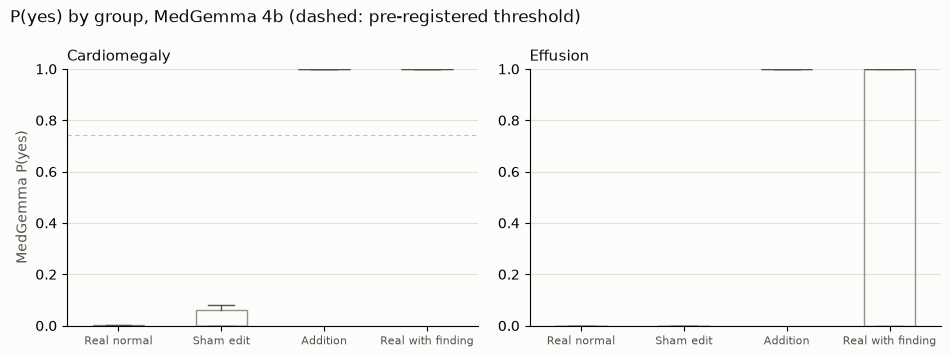

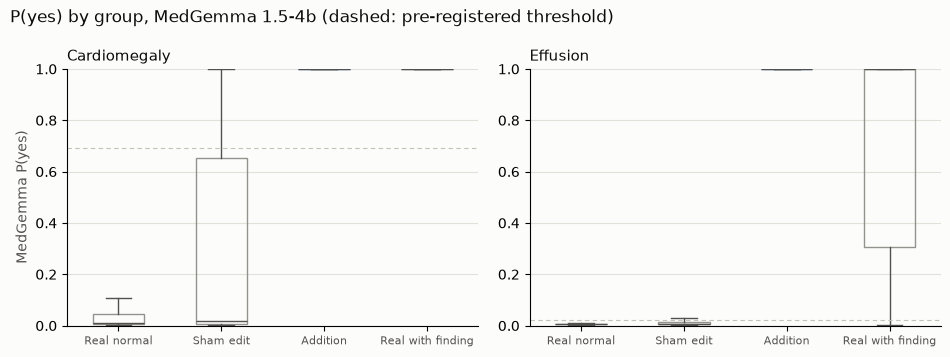

In [8]:
groups = [("Real normal", "original"), ("Sham edit", "sham"), ("Addition", "edit"), ("Real with finding", "real_finding")]
for m in models:
    findings = sorted(wide[m]["finding"].unique())
    fig, axes = plt.subplots(1, len(findings), figsize=(4.8 * len(findings), 3.6), facecolor=SURFACE, squeeze=False)
    for ax, finding in zip(axes[0], findings):
        g = wide[m][(wide[m]["finding"] == finding) & (wide[m]["phrasing"] == 0)]
        data = [g.loc[g["valid"], f"p_{col}"] if col == "edit" else g[f"p_{col}"] for _, col in groups]
        parts = ax.boxplot(data, widths=0.5, showfliers=False, patch_artist=True)
        for k, box in enumerate(parts["boxes"]):
            box.set(facecolor=ACCENT if groups[k][1] == "edit" else "none",
                    edgecolor=ACCENT if groups[k][1] == "edit" else MUTED, alpha=0.9)
        for key in ["whiskers", "caps", "medians"]:
            for line in parts[key]:
                line.set(color=INK_2, linewidth=1)
        ax.axhline(g["threshold"].iloc[0], color=AXIS, linewidth=0.8, linestyle=(0, (4, 3)))
        ax.set_xticks(range(1, 5), [name for name, _ in groups], fontsize=8, color=INK_2)
        ax.set_ylim(0, 1)
        ax.set_title(finding.capitalize(), loc="left", color=INK, fontsize=11)
        ax.set_facecolor(SURFACE)
        ax.grid(axis="y", color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
        for side in ["top", "right"]:
            ax.spines[side].set_visible(False)
    axes[0, 0].set_ylabel("MedGemma P(yes)", color=INK_2)
    fig.suptitle(f"P(yes) by group, MedGemma {m} (dashed: pre-registered threshold)", x=0.01, ha="left", color=INK, fontsize=12)
    fig.tight_layout()
    fig.savefig(R / f"audit_groups_{m}.png", dpi=200, facecolor=SURFACE)
    plt.show()

## Sham breakdown: anatomical change or editing traces?

A sham uses the same mask, seed and edit path as the addition, with the normal prompt. The checks
measure what it did to the film: the classifiers' scores, the CTR (cardiomegaly) and the aerated
lung area in the mask (effusion; negative = shrinks). "No measured change": the classifier scores
not up (for effusion, the PadChest one, and in a second row both classifiers), and the CTR not up or
the lung area not down. Pre-registered threshold, eligibility as in the flip rule; every source
film is used, whether or not its addition passed the checks.

In [9]:
checks["d_pc"] = checks["p_after:densenet121-res224-pc"] - checks["p_before:densenet121-res224-pc"]
checks["d_chex"] = checks["p_after:densenet121-res224-chex"] - checks["p_before:densenet121-res224-chex"]
checks["d_ctr"] = checks["ctr_after"] - checks["ctr_before"]
sham_checks = checks[checks["kind"] == "sham"][["finding", "image", "valid", "d_pc", "d_chex", "d_ctr", "lung_area_change"]]
sham_checks = sham_checks.rename(columns={"valid": "sham_valid"})

def no_change(d, both=False):
    anatomy = np.where(d["finding"] == "cardiomegaly", d["d_ctr"] <= 0, d["lung_area_change"] >= 0)
    classifiers = (d["d_pc"] <= 0) & ((d["d_chex"] <= 0) | (d["finding"] == "cardiomegaly") | (not both))
    return classifiers & anatomy

rows = []
for m in models:
    w = wide[m].drop(columns="valid").merge(sham_checks, on=["finding", "image"])
    w = w[w["original"] < w["threshold_log_odds"]]
    for (finding, phrasing), g in w.groupby(["finding", "phrasing"]):
        subsets = [("passes the checks", g[g["sham_valid"]]), ("fails the checks", g[~g["sham_valid"]]),
                   ("no measured change", g[no_change(g)])]
        if finding == "effusion":
            subsets.append(("no measured change, both classifiers", g[no_change(g, both=True)]))
        for subset, d in subsets:
            flip = lambda x: (x["sham"] > x["threshold_log_odds"]).mean()
            shift = lambda x: (x["sham"] - x["original"]).mean()
            lo, hi = patient_ci(d, flip)
            slo, shi = patient_ci(d, shift)
            rows.append({"model": m, "finding": finding, "phrasing": phrasing, "shams": subset, "n": len(d),
                         "flip_sham": flip(d) if len(d) else np.nan, "ci_low": lo, "ci_high": hi,
                         "mean_change_log_odds": shift(d) if len(d) else np.nan, "lo_ci_low": slo, "lo_ci_high": shi})
sham_table = pd.DataFrame(rows)
sham_table.to_csv(R / "audit_sham_breakdown.csv", index=False)
sham_table.round(3)

,model,finding,phrasing,shams,n,flip_sham,ci_low,ci_high,mean_change_log_odds,lo_ci_low,lo_ci_high
0,4b,cardiomegaly,0,passes the checks,16,1.000,1.000,1.000,21.174,19.190,22.908
1,4b,cardiomegaly,0,fails the checks,322,0.127,0.093,0.165,2.722,2.095,3.391
2,4b,cardiomegaly,0,no measured change,82,0.049,0.012,0.098,0.054,-0.617,0.820
3,4b,cardiomegaly,1,passes the checks,16,1.000,1.000,1.000,17.325,12.908,21.729
4,4b,cardiomegaly,1,fails the checks,318,0.138,0.104,0.173,1.246,0.830,1.708
5,4b,cardiomegaly,1,no measured change,81,0.049,0.012,0.111,-0.096,-0.238,0.055
6,4b,effusion,0,passes the checks,1,0.000,NaN,NaN,2.853,NaN,NaN
7,4b,effusion,0,fails the checks,531,0.075,0.053,0.100,0.454,0.310,0.617
8,4b,effusion,0,no measured change,145,0.034,0.007,0.069,0.127,0.055,0.205
9,4b,effusion,0,"no measured change, both classifiers",75,0.027,0.000,0.067,0.091,-0.001,0.182


Cardiomegaly shams that fail the checks: flip rate by the CTR change the sham caused.

In [10]:
rows = []
for m in models:
    w = wide[m].drop(columns="valid").merge(sham_checks, on=["finding", "image"])
    w = w[(w["original"] < w["threshold_log_odds"]) & ~w["sham_valid"] & (w["finding"] == "cardiomegaly")].copy()
    w["ctr_change"] = pd.cut(w["d_ctr"], [-1, 0, 0.02, 0.04, 0.06, 1], labels=["<= 0", "0 to 0.02", "0.02 to 0.04", "0.04 to 0.06", "> 0.06"])
    for (phrasing, band), g in w.groupby(["phrasing", "ctr_change"], observed=True):
        rows.append({"model": m, "phrasing": phrasing, "ctr_change": band, "n": len(g),
                     "flip_sham": (g["sham"] > g["threshold_log_odds"]).mean()})
by_ctr = pd.DataFrame(rows)
by_ctr.to_csv(R / "audit_sham_by_ctr_change.csv", index=False)
by_ctr.pivot_table(index="ctr_change", columns=["model", "phrasing"], values=["n", "flip_sham"], observed=True).round(3)

flip_sham                           n                     
model           1.5-4b            4b        1.5-4b            4b       
phrasing             0      1      0      1      0      1      0      1
ctr_change                                                             
0 to 0.02        0.051  0.037  0.025  0.026   78.0   81.0   79.0   76.0
0.02 to 0.04     0.259  0.250  0.214  0.250   27.0   28.0   28.0   28.0
0.04 to 0.06     0.409  0.227  0.391  0.391   22.0   22.0   23.0   23.0
<= 0             0.070  0.051  0.053  0.065  172.0  175.0  170.0  169.0
> 0.06           0.818  0.682  0.682  0.682   22.0   22.0   22.0   22.0

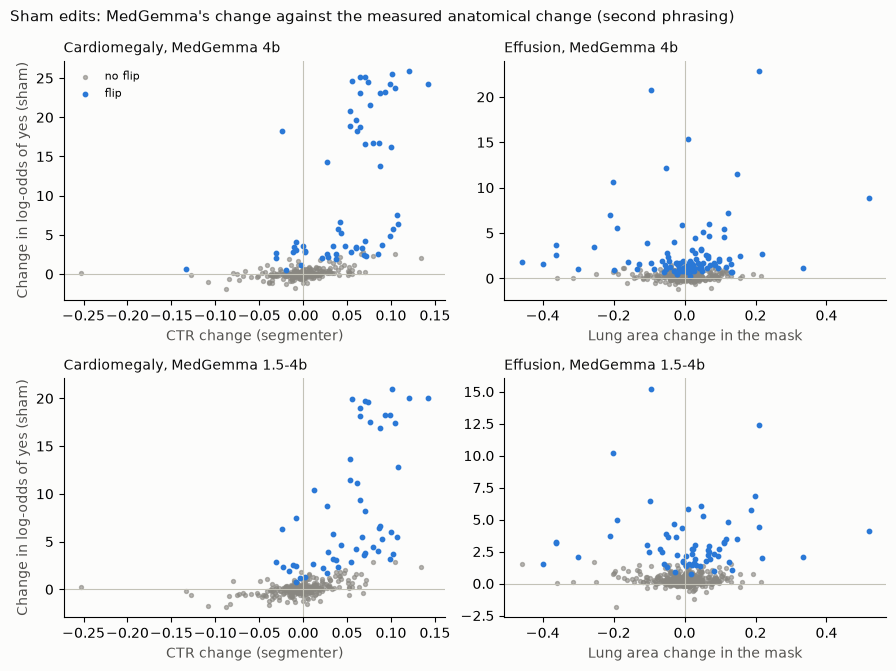

In [11]:
fig, axes = plt.subplots(len(models), 2, figsize=(9, 3.4 * len(models)), facecolor=SURFACE, squeeze=False)
for i, m in enumerate(models):
    w = wide[m].drop(columns="valid").merge(sham_checks, on=["finding", "image"])
    w = w[(w["phrasing"] == 1) & (w["original"] < w["threshold_log_odds"])]
    for ax, (finding, x, label) in zip(axes[i], [("cardiomegaly", "d_ctr", "CTR change (segmenter)"),
                                                  ("effusion", "lung_area_change", "Lung area change in the mask")]):
        g = w[w["finding"] == finding]
        flipped = g["sham"] > g["threshold_log_odds"]
        y = g["sham"] - g["original"]
        ax.scatter(g.loc[~flipped, x], y[~flipped], s=8, color=MUTED, alpha=0.6, label="no flip")
        ax.scatter(g.loc[flipped, x], y[flipped], s=10, color=ACCENT, label="flip")
        ax.axhline(0, color=AXIS, linewidth=0.8)
        ax.axvline(0, color=AXIS, linewidth=0.8)
        ax.set_xlabel(label, color=INK_2)
        ax.set_title(f"{finding.capitalize()}, MedGemma {m}", loc="left", color=INK, fontsize=10)
        ax.set_facecolor(SURFACE)
        for side in ["top", "right"]:
            ax.spines[side].set_visible(False)
    axes[i, 0].set_ylabel("Change in log-odds of yes (sham)", color=INK_2)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("Sham edits: MedGemma's change against the measured anatomical change (second phrasing)",
             x=0.01, ha="left", color=INK, fontsize=11)
fig.tight_layout()
fig.savefig(R / "audit_sham_vs_anatomy.png", dpi=200, facecolor=SURFACE)
plt.show()

Effusion shams with no measured change (both classifiers) that flip under the pre-registered rule
for at least one model and phrasing, on the re-scored data, next to the list behind the galleries
inspected on 2026-09-30 (`results/effusion_sham_gallery.csv`, old scores).

In [12]:
rows = []
for m in models:
    w = wide[m].drop(columns="valid").merge(sham_checks, on=["finding", "image"])
    w = w[(w["finding"] == "effusion") & (w["original"] < w["threshold_log_odds"]) & no_change(w, both=True)]
    rows.append(w.assign(model=m, flip=w["sham"] > w["threshold_log_odds"]))
w = pd.concat(rows)
gallery = w.groupby("image").agg(n_flips=("flip", "sum"), n_scored=("flip", "size")).reset_index()
gallery = gallery[gallery["n_flips"] > 0].sort_values("n_flips", ascending=False)
gallery.to_csv(R / "effusion_sham_gallery_rescored.csv", index=False)
old = pd.read_csv(R / "effusion_sham_gallery.csv")
old = set(old.loc[old["group"] == "flip", "image"])
print(f"Re-scored list: {len(gallery)} shams; in the inspected galleries: {len(old & set(gallery['image']))}; "
      f"new: {len(set(gallery['image']) - old)}; inspected but no longer flipping: {len(old - set(gallery['image']))}")

Re-scored list: 12 shams; in the inspected galleries: 8; new: 4; inspected but no longer flipping: 12


## The checks' own measures, per group

The classifier's score and the segmenter's CTR for real normal films (originals), shams and
additions that passed the checks.

In [13]:
rows = []
for finding, g in checks.groupby("finding"):
    for name, d, col in [("Real normal", g[g["kind"] == "edit"], "before"), ("Sham edit", g[g["kind"] == "sham"], "after"),
                         ("Addition", g[(g["kind"] == "edit") & g["valid"]], "after")]:
        row = {"finding": finding, "group": name, "n": len(d), "classifier_median": d[f"p_{col}:densenet121-res224-pc"].median()}
        if finding == "cardiomegaly":
            row["ctr_median"] = d[f"ctr_{col}"].median()
            row["share_ctr_above_0.5"] = (d[f"ctr_{col}"] > 0.5).mean()
        rows.append(row)
pd.DataFrame(rows).round(3)

,finding,group,n,classifier_median,ctr_median,share_ctr_above_0.5
0,cardiomegaly,Real normal,380,0.016,0.422,0.005
1,cardiomegaly,Sham edit,380,0.029,0.423,0.058
2,cardiomegaly,Addition,308,0.624,0.551,1.000
3,effusion,Real normal,600,0.048,NaN,NaN
4,effusion,Sham edit,600,0.052,NaN,NaN
5,effusion,Addition,179,0.920,NaN,NaN


## Reliability of P(yes)

Test originals (normal, label 0) and the real films with the finding shown as a control (label 1).
Half the images carry the finding, far more than in practice, so this shows the shape of the
miscalibration, not its size at real prevalence. The real films with the finding are drawn with
replacement, so some appear several times.

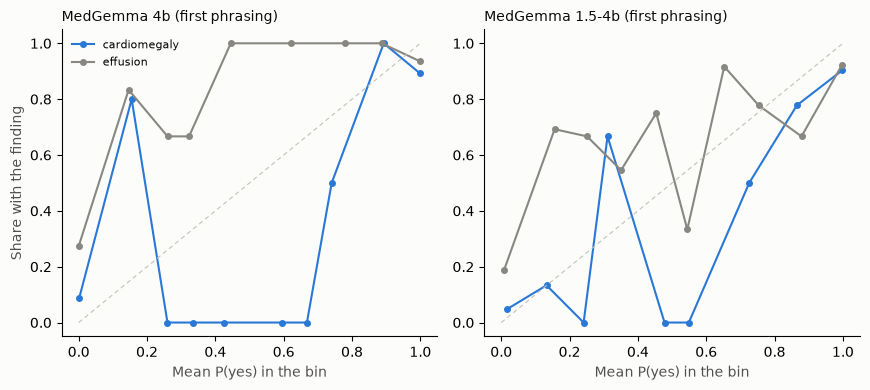

,model,finding,share_p_below_0.01,share_p_above_0.99,observed_rate_when_p_below_0.01
0,4b,cardiomegaly,0.453,0.482,0.067
1,4b,effusion,0.650,0.312,0.272
2,1.5-4b,cardiomegaly,0.255,0.489,0.036
3,1.5-4b,effusion,0.488,0.357,0.150


In [14]:
bins = np.linspace(0, 1, 11)
fig, axes = plt.subplots(1, len(models), figsize=(4.4 * len(models), 4), facecolor=SURFACE, squeeze=False)
rows = []
for ax, m in zip(axes[0], models):
    w = wide[m][wide[m]["phrasing"] == 0]
    for finding, g in w.groupby("finding"):
        p = np.concatenate([g["p_original"], g["p_real_finding"]])
        y = np.concatenate([np.zeros(len(g)), np.ones(len(g))])
        k = np.clip(np.digitize(p, bins) - 1, 0, 9)
        ax.plot([p[k == b].mean() for b in range(10) if (k == b).any()], [y[k == b].mean() for b in range(10) if (k == b).any()],
                marker="o", markersize=4, color=ACCENT if finding == "cardiomegaly" else MUTED, label=finding)
        rows.append({"model": m, "finding": finding, "share_p_below_0.01": (p < 0.01).mean(), "share_p_above_0.99": (p > 0.99).mean(),
                     "observed_rate_when_p_below_0.01": y[p < 0.01].mean() if (p < 0.01).any() else np.nan})
    ax.plot([0, 1], [0, 1], color=AXIS, linewidth=0.8, linestyle=(0, (4, 3)))
    ax.set_xlabel("Mean P(yes) in the bin", color=INK_2)
    ax.set_title(f"MedGemma {m} (first phrasing)", loc="left", color=INK, fontsize=10)
    ax.set_facecolor(SURFACE)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
axes[0, 0].set_ylabel("Share with the finding", color=INK_2)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(R / "audit_reliability.png", dpi=200, facecolor=SURFACE)
plt.show()
reliability = pd.DataFrame(rows)
reliability.to_csv(R / "audit_reliability.csv", index=False)
reliability.round(3)

## Day-4 decision rule, step 1, on the re-scored data

As fixed on 2026-09-29 (shams that fail the checks, CI lower bound above 5% for both phrasings of a
model and finding) and as amended on 2026-09-30 (shams with no measured change).

In [15]:
for subset in ["fails the checks", "no measured change"]:
    f = sham_table[sham_table["shams"] == subset]
    hit = f.groupby(["model", "finding"]).apply(lambda g: bool((g["ci_low"] > 0.05).all()) and len(g) == 2, include_groups=False)
    print(f"{subset}: step 1 would apply for", [k for k, v in hit.items() if v] or "no model and finding")

fails the checks: step 1 would apply for [('1.5-4b', 'cardiomegaly'), ('1.5-4b', 'effusion'), ('4b', 'cardiomegaly'), ('4b', 'effusion')]
no measured change: step 1 would apply for no model and finding


## Takeaways

In [16]:
for rule in ["0.5", "pre-registered"]:
    for _, r in flips[(flips["subset"] == "all") & (flips["rule"] == rule)].iterrows():
        print(f"{rule}: MedGemma {r['model']}, {r['finding']}, phrasing {r['phrasing']}: {r['flips_edit']}/{r['n_eligible_edit']} "
              f"additions flip ({r['flip_edit']:.1%}, one-sided 95% lower bound {r['one_sided_95_lower']:.1%}); "
              f"shams {r['flip_sham']:.1%} of {r['n_eligible_sham']}.")
c = controls[controls["variant"] == "blank"]
print("Blank images with P(yes) > 0.5:", {f"{r.model} {r.finding} {r.phrasing}": round(r.share_above_05, 3) for r in c.itertuples()},
      "; largest P(yes):", round(c["max_p_yes"].max(), 4))

0.5: MedGemma 4b, cardiomegaly, phrasing 0: 266/266 additions flip (100.0%, one-sided 95% lower bound 98.9%); shams 20.3% of 266.
0.5: MedGemma 4b, cardiomegaly, phrasing 1: 289/293 additions flip (98.6%, one-sided 95% lower bound 96.9%); shams 9.2% of 293.
0.5: MedGemma 4b, effusion, phrasing 0: 168/169 additions flip (99.4%, one-sided 95% lower bound 97.2%); shams 2.4% of 169.
0.5: MedGemma 4b, effusion, phrasing 1: 163/163 additions flip (100.0%, one-sided 95% lower bound 98.2%); shams 4.9% of 163.
0.5: MedGemma 1.5-4b, cardiomegaly, phrasing 0: 265/265 additions flip (100.0%, one-sided 95% lower bound 98.9%); shams 22.6% of 265.
0.5: MedGemma 1.5-4b, cardiomegaly, phrasing 1: 284/285 additions flip (99.6%, one-sided 95% lower bound 98.3%); shams 11.9% of 285.
0.5: MedGemma 1.5-4b, effusion, phrasing 0: 163/163 additions flip (100.0%, one-sided 95% lower bound 98.2%); shams 4.3% of 163.
0.5: MedGemma 1.5-4b, effusion, phrasing 1: 158/158 additions flip (100.0%, one-sided 95% lower b